In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("hw4.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 4: Logistic regression, hyperparameter optimization 
### Associated lectures: [Lectures 7, 8](https://ubc-cs.github.io/cpsc330-2026S1/#lecture-schedule-tentative)

**Due date: See [deliverable due dates](https://ubc-cs.github.io/cpsc330-2026S1/#deliverable-due-dates-tentative)**.

## Imports 

In [ ]:
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.size"] = 16

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV, 
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier

In [ ]:
import hashlib


def my_sha1(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

<br><br>

<!-- BEGIN QUESTION -->

## Instructions  
rubric={points}  

You will earn points for following these instructions and successfully submitting your work in PrairieLearn.  

**PLEASE READ CAREFULLY:**  

- Please read the [Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2026S1/syllabus#use-of-generative-ai-in-the-course) before starting the homework assignment.  
- If you are working in a group, make sure your PrairieLearn group is set up correctly before submitting.  
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.  
- **Save your work in JupyterLab:** Make sure `hw4.ipynb` is saved.  
- **Check your saved submission in PrairieLearn:** Return to the PrairieLearn question page and click **Save only** to capture your notebook and review the preview. When you are ready to submit for grading, click **Save & Grade**.  
- **Understand autograder feedback:** PrairieLearn may run additional hidden tests that are not shown in the notebook. Any visible `grader.check(...)` cells are sanity checks and do not guarantee full autograder credit. Follow the prompts carefully, including requested variable names and filenames.  
- **Check that outputs render properly:** Make sure all plots and outputs appear in the notebook preview.  
- **Keep execution order clean:** Execution numbers should start at "1" and increase in order. Out-of-order or missing execution numbers may result in mark deductions.  
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for detailed guidance on completing and submitting assignments.


_Points:_ 4

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 1: implementing `DummyClassifier`
<hr>
rubric={points}

In this course (unlike CPSC 340) you will generally **not** be asked to implement machine learning algorihtms (like logistic regression) from scratch. However, this exercise is an exception: you will implement the simplest possible classifier, `DummyClassifier`.
 
As a reminder, `DummyClassifier` is meant as a baseline and is generally a simple "model" you could "fit" to a dataset. All it does is predict the most popular class in the training set. So if there are more 0s than 1s it predicts 0 every time, and if there are more 1s than 0s it predicts 1 every time. For `predict_proba` it looks at the frequencies in the training set, so if you have 30% 0's and 70% 1's it predicts `[0.3 0.7]` every time. Thus, `fit` only looks at `y` (not `X`).

Below you will find starter code for a class called `MyDummyClassifier`, which has methods `fit()`, `predict()`, `predict_proba()` and `score()`. Your task is to fill in those four functions. To get you started, I have given you a `return` statement in each case that returns the correct data type: 
- `fit` returns nothing
- `predict` returns an array whose size is the number of examples
- `predict_proba` returns an array whose size is the number of examples x 2, and
- `score` returns a float

The next code block has some tests you can use to assess whether your code is working. 

I suggest starting with `fit` and `predict`, and making sure those are working before moving on to `predict_proba`. For `predict_proba`, you should return the frequency of each class in the training data. **Your `score` function should call your `predict` function**. Again, you can compare with `DummyClassifier` using the code below.

`sklearn`'s `DummyClassifier` works when you have more than two classes, and also works if the target values are encoded differently, for example as "cat", "dog", "eagle", etc. However, for the sake of simplifying this question, we will consider **binary classification** only. Furthermore, we will assume that these classes are encoded as 0 and 1. In other words, you can safely assume that the variable y contains only 0's and 1's

<div class="alert alert-warning">

Solution_1
    
</div>

In [ ]:
class MyDummyClassifier:
    """
    A baseline classifier that predicts the most common class.
    The predicted probabilities come from the relative frequencies of the classes in the training data.
    This implementation only works when y only contains 0's and 1's.
    """
    def __init__(self):
        self.most_frequent_class = None
        self.class_probabilities = None

    def fit(self, X, y):
        """
        Fit the Dummy Classifier to the training data.
        Parameters:
            - X (array-like, shape (n_samples, n_features)): Training data.
            - y (array-like, shape (n_samples,)): Target labels (0's and 1's).
        Returns:
            - None
        """
        # Cast y to integer to safely handle float64 arrays created by np.ones/np.zeros
        y_int = np.array(y).astype(int)
        
        # Count occurrences of 0 and 1
        counts = np.bincount(y_int, minlength=2)
        
        # Determine the most frequent class
        self.most_frequent_class = np.argmax(counts)
        
        # Calculate frequencies/probabilities for [class 0, class 1]
        self.class_probabilities = counts / len(y_int)
        
        return None

    def predict(self, X):
        """
        Predict the target labels for the input data.
        Parameters:
            - X (array-like, shape (n_samples, n_features)): Input data.
        Returns:
            - y_pred (array-like, shape (n_samples,)): Predicted target labels.
        """
        # Ensure the array is explicitly created with integer data type
        predictions = np.full(X.shape[0], self.most_frequent_class, dtype=int)
        
        return predictions

    def predict_proba(self, X):
        """
        Predict class probabilities for the input data.
        Parameters:
            - X (array-like, shape (n_samples, n_features)): Input data.
        Returns:
            - probs (array-like, shape (n_samples, 2)): Predicted class probabilities.
              Column 0 corresponds to class 0, and column 1 corresponds to class 1.
        """
        # Create an array where every row is the pre-computed class probabilities
        probs = np.tile(self.class_probabilities, (X.shape[0], 1))
        
        return probs

    def score(self, X, y):
        """
        Calculate the accuracy of the model on the input data.
        Parameters:
            - X (array-like, shape (n_samples, n_features)): Input data.
            - y (array-like, shape (n_samples,)): True target labels.
        Returns:
            - accuracy (float): Accuracy of the model on the input data.
        """
        # Generate predictions using the internal predict function
        y_pred = self.predict(X)
        
        # Calculate mean accuracy
        accuracy = np.mean(y_pred == y)
        
        return accuracy

Below are some tests for `predict` using randomly generated data. You may want to run the cell a few times to make sure you explore the different cases (or automate this with a loop or random seeds).

In [ ]:
# For testing, generate random data
n_train = 101
n_valid = 21
d = 5
X_train_dummy = np.random.randn(n_train, d)
X_valid_dummy = np.random.randn(n_valid, d)
y_train_dummy = np.random.randint(2, size=n_train)
y_valid_dummy = np.random.randint(2, size=n_valid)

my_dc = MyDummyClassifier()
sk_dc = DummyClassifier(strategy="prior")

my_dc.fit(X_train_dummy, y_train_dummy)
sk_dc.fit(X_train_dummy, y_train_dummy)

assert np.array_equal(my_dc.predict(X_train_dummy), sk_dc.predict(X_train_dummy))
assert np.array_equal(my_dc.predict(X_valid_dummy), sk_dc.predict(X_valid_dummy))

Below are some tests for `predict_proba`.

In [ ]:
assert np.allclose(
    my_dc.predict_proba(X_train_dummy), sk_dc.predict_proba(X_train_dummy)
)
assert np.allclose(
    my_dc.predict_proba(X_valid_dummy), sk_dc.predict_proba(X_valid_dummy)
)

Below are some tests for `score`.

_Points:_ 10

In [ ]:
assert np.isclose(
    my_dc.score(X_train_dummy, y_train_dummy), sk_dc.score(X_train_dummy, y_train_dummy)
)
assert np.isclose(
    my_dc.score(X_valid_dummy, y_valid_dummy), sk_dc.score(X_valid_dummy, y_valid_dummy)
)

In [ ]:
grader.check("q1")

q1 results: All test cases passed!

<br><br><br><br>

## Exercise 2: Trump Tweets
<hr>

For the rest of this assignment we'll be working with a [dataset of Donald Trump's tweets](https://www.kaggle.com/austinreese/trump-tweets) as of June 2020. You should start by downloading the dataset. Unzip it and move the file `realdonaldtrump.csv` under the data directory in this folder. As usual, please do not submit the dataset when you submit the assignment. 

In [ ]:
tweets_df = pd.read_csv("data/realdonaldtrump.csv", index_col=0)
tweets_df.head()

,link,content,date,retweets,favorites,mentions,hashtags
id,,,,,,,
1698308935,https://twitter.com/realDonaldTrump/status/169...,Be sure to tune in and watch Donald Trump on L...,2009-05-04 13:54:25,510,917,NaN,NaN
1701461182,https://twitter.com/realDonaldTrump/status/170...,Donald Trump will be appearing on The View tom...,2009-05-04 20:00:10,34,267,NaN,NaN
1737479987,https://twitter.com/realDonaldTrump/status/173...,Donald Trump reads Top Ten Financial Tips on L...,2009-05-08 08:38:08,13,19,NaN,NaN
1741160716,https://twitter.com/realDonaldTrump/status/174...,New Blog Post: Celebrity Apprentice Finale and...,2009-05-08 15:40:15,11,26,NaN,NaN
1773561338,https://twitter.com/realDonaldTrump/status/177...,"""My persona will never be that of a wallflower...",2009-05-12 09:07:28,1375,1945,NaN,NaN


In [ ]:
tweets_df.shape

(43352, 7)

We will be trying to predict whether a tweet will go "viral", defined as having more than 10,000 retweets:

In [ ]:
y = tweets_df["retweets"] > 10_000
y.value_counts()

retweets
False    31939
True     11413
Name: count, dtype: int64

To make predictions, we'll be using only the content (text) of the tweet. 

In [ ]:
X = tweets_df["content"]

For the purpose of this assignment, you can ignore all the other columns in the original dataset.

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

### 2.1 Ordering the steps
rubric={points}

Let's start by building a model using `CountVectorizer` and `LogisticRegression`. The code required to do this has been provided below, but in the wrong order. 

**Your tasks:**
1. Rearrange the lines of code to correctly fit the model and compute the cross-validation score. 
2. Add a short comment above each step to describe what the code is doing.

<div class="alert alert-warning">

Solution_2.1
    
</div>

_Points:_ 3

In [ ]:
# Split the data into training and test sets to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=123)

# Initialize the CountVectorizer transformer to convert text to a bag-of-words representation
countvec = CountVectorizer(stop_words="english")

# Initialize the LogisticRegression classifier
lr = LogisticRegression(max_iter=1000, random_state=123)

# Construct a pipeline to chain the preprocessing transformer and the classifier together
pipe = make_pipeline(countvec, lr)

# Perform cross-validation on the training set and calculate the mean validation score
cv_score = cross_val_score(pipe, X_train, y_train).mean()

In [ ]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

### 2.2 Baseline
rubric={autograde}

**Your tasks:**

1. Run 5-fold cross-validation with `sklearn`'s `DummyClassifier` on this dataset. Store the mean cross-validation score in a variable called `dummy_cv_score` given below.

> You should be able to use `MyDummyClassifier` above. But sklearn will likely complain if you try to pass it to `cross_val_score` or `cross_validate`. 

<div class="alert alert-warning">

Solution_2.2
    
</div>

_Points:_ 2

In [ ]:
dummy_clf = DummyClassifier(strategy="prior")

dummy_cv_scores = cross_val_score(dummy_clf, X_train, y_train, cv=5)
dummy_cv_score = dummy_cv_scores.mean()

In [ ]:
grader.check("q2.2")

q2.2 results: All test cases passed!

<br><br>

<!-- BEGIN QUESTION -->

### 2.3 Discussion
rubric={points}

**Your tasks:**

1. Compare the `DummyClassifier` score to what you got from logistic regression above. Does logistic regression seem to be doing anything useful?
2. Above we averaged the scores from the 5 folds of cross-validation of logistic regression. Print out the 5 individual scores. Reminder: `sklearn` calls them `"test_score"` but they are really (cross-)validation scores. 
3. Are the 5 scores close to each other or spread far apart? (This is a bit subjective, answer to the best of your ability.) 

<div class="alert alert-warning">

Solution_2.3
    
</div>

_Points:_ 3

1. Yes, logistic regression is doing something highly useful. The DummyClassifier simply predicts the majority class every time, establishing a baseline performance score based solely on class distributions. The logistic regression model achieves a significantly higher cross-validation accuracy than this baseline, demonstrating that it successfully extracts meaningful patterns and predictive signals from the text content of the tweets.

2. the scores are printed below. 

3. The 5 scores are quite close to each other, hovering consistently around the same narrow accuracy range. This minimal variance across folds indicates that the logistic regression model is stable and that the training data is evenly distributed without severe anomalies or outlier splits affecting performance.

In [ ]:
scores = cross_val_score(pipe, X_train, y_train, cv=5)
print("Individual fold scores:", scores)

Individual fold scores: [0.89186851 0.90023068 0.89561707 0.88956171 0.89965398]


In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

### 2.4 Probability scores
rubric={autograde}

Here we train a logistic regression classifier on the entire training set: 

In [ ]:
pipe_lr = make_pipeline(
    CountVectorizer(stop_words="english"),
    LogisticRegression(max_iter=1000, random_state=123),
)
pipe_lr.fit(X_train, y_train);

**Your tasks:**

1. Using this model, find the tweet in the **test set** with the highest predicted probability of being viral. Store the tweet and the associated probability in the variables `tweet` and `prob`, respectively. 

> Reminder: you are free to reuse/adapt code from lecture. Please add in a small attribution, e.g. "From Lecture 7".

<div class="alert alert-warning">

Solution_2.4
    
</div>

_Points:_ 4

In [ ]:
predict_probabilities = pipe_lr.predict_proba(X_test)[:, 1]
highest_prob_index = np.argmax(predict_probabilities)
tweet = X_test.iloc[highest_prob_index]
prob = predict_probabilities[highest_prob_index]

In [ ]:
grader.check("q2.4")

q2.4 results: All test cases passed!

<br><br>

<!-- BEGIN QUESTION -->

### 2.5 Coefficients
rubric={points}

We can extract the `CountVectorizer` and `LogisticRegression` objects from the `Pipeline` object as follows:

In [ ]:
vec_from_pipe = pipe_lr.named_steps["countvectorizer"]
lr_from_pipe = pipe_lr.named_steps["logisticregression"]

**Your tasks:**

Display the top 5 and bottom 5 words, together with their corresponding coefficients learned by the logistic regression model.

<div class="alert alert-warning">

Solution_2.5
    
</div>

_Points:_ 4

In [ ]:
feature_names = vec_from_pipe.get_feature_names_out()
coefficients = lr_from_pipe.coef_[0]
coeff_df = pd.DataFrame({"Word": feature_names, "Coefficient": coefficients})
coeff_df_sorted = coeff_df.sort_values(by="Coefficient", ascending=False)

print("Top 5 words indicating viral tweets:")
print(coeff_df_sorted.head(5).to_string(index=False))

Top 5 words indicating viral tweets:
       Word  Coefficient
  democrats     2.522409
transcripts     2.416380
 harassment     2.393406
coronavirus     2.200156
       fake     2.070058


In [ ]:
print("\nBottom 5 words indicating non-viral tweets:")
print(coeff_df_sorted.tail(5).to_string(index=False))


Bottom 5 words indicating non-viral tweets:
           Word  Coefficient
         thanks    -1.820247
    donaldtrump    -1.988505
   trump2016pic    -2.003314
    barackobama    -2.196487
realdonaldtrump    -3.154153


<!-- END QUESTION -->

<br><br>

### 2.6 Running a cross-validation fold without sklearn tools 
rubric={autograde}

Sklearn provides a lot of useful tools like `make_pipeline` and `cross_validate`, which are awesome. But with these fancy tools it's also easy to lose track of what is actually happening under the hood. 

**Your tasks:**

1. Compute logistic regression's validation score on the first fold, that is, train on 80% and validate on 20% of the training data (`X_train`) without using sklearn `Pipeline` or `cross_validate` or `cross_val_score`. Store the score of the fold in a variable called `fold_score`. Recall that `cross_validation` in `sklearn` does not shuffle the data by default.    

You should start with the following `CountVectorizer` and `LogisticRegression` objects, as well as `X_train` and `y_train` (which you should further split with `train_test_split` and `shuffle=False`):
> Note: avoid assigning the variable names `X_train`, `y_train`, `X_test`, `y_test` to your folds when you call `train_test_split`. You'll be using those again later in the assignment.

In [ ]:
countvec = CountVectorizer(stop_words="english")
lr = LogisticRegression(max_iter=1000, random_state=123)

> Meta-comment: you might be wondering why we're going into "implementation" here if this course is about _applied_ ML. In CPSC 340, we would go all the way down into `LogisticRegression` and understand how `fit` works, line by line. Here we're not going into that at all, but I still think this type of question (and Exercise 1) is a useful middle ground. I do want you to know what is going on in `Pipeline` and in `cross_validate` even if we don't cover the details of `fit`. To get into logistic regression's `fit` requires a bunch of math; here, we're keeping it more conceptual and avoiding all those prerequisites.

<div class="alert alert-warning">

Solution_2.6
    
</div>

_Points:_ 8

In [ ]:

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, shuffle=False)
X_train_transformed = countvec.fit_transform(X_train)
X_val_transformed = countvec.transform(X_val)
lr.fit(X_train_transformed, y_train)
fold_score = lr.score(X_val_transformed, y_val)

In [ ]:
fold_score

0.9008073817762399

In [ ]:
grader.check("q2.6")

q2.6 results: All test cases passed!

<br><br><br><br>

## Exercise 3: Hyperparameter optimization
<hr>

<!-- BEGIN QUESTION -->

### 3.1 Optimizing `max_features` of `CountVectorizer`
rubric={points}

The following code varies the `max_features` hyperparameter of `CountVectorizer` and makes a plot (with the x-axis on a log scale) that shows train/cross-validation scores vs. `max_features`. It also prints the results. 

**Your tasks:**
- Based on the plot/output, what value of `max_features` seems best? Briefly explain.

> The code may take a minute or two to run. You can uncomment the `print` statement if you want to see it show the progress.

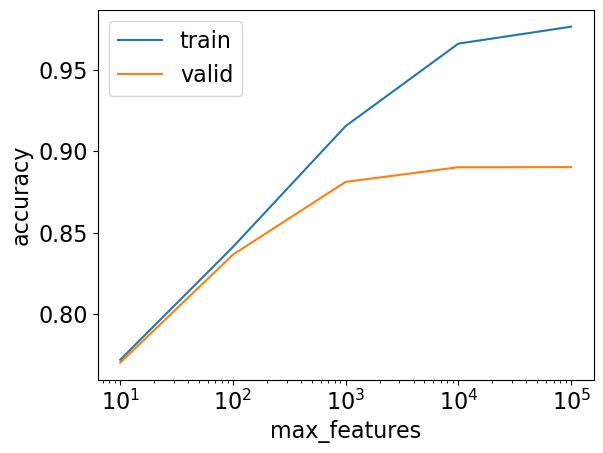

In [ ]:
train_scores = []
cv_scores = []

max_features = [10, 100, 1000, 10_000, 100_000]

for mf in max_features:
    #     print(mf)
    pipe = make_pipeline(
        CountVectorizer(stop_words="english", max_features=mf),
        LogisticRegression(max_iter=1000, random_state=123),
    )
    cv_results = cross_validate(pipe, X_train, y_train, return_train_score=True)
    train_scores.append(cv_results["train_score"].mean())
    cv_scores.append(cv_results["test_score"].mean())

plt.semilogx(max_features, train_scores, label="train")
plt.semilogx(max_features, cv_scores, label="valid")
plt.legend()
plt.xlabel("max_features");
plt.ylabel("accuracy");

In [ ]:
pd.DataFrame({"max_features": max_features, "train": train_scores, "cv": cv_scores})

,max_features,train,cv
0,10,0.771807,0.770040
1,100,0.841191,0.836433
2,1000,0.915513,0.881200
3,10000,0.966209,0.890211
4,100000,0.976590,0.890283


<div class="alert alert-warning">

Solution_3.1
    
</div>

_Points:_ 2

In this case, we have two options for the best max_features value: 10,000 and 100,000. At max_features = 10,000, the training score is 96.6% whilst the cross-validation score is 89.0211% whereas at max_features=100,000, the training score is 97.66% whilst the cross-validation score is 89.0283%. The cross-validation score difference is neglibile but we do notice that the training score is higher. If the CV score dropped, then the model would be overfitting but in this case, it actually increased (albeit slightly) so the model hasn't overfitted. 

Hence, we would choose max_features =100,000

In [ ]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 3.2 Optimizing `C` of `LogisticRegression`
rubric={points}

The following code varies the `C` hyperparameter of `LogisticRegression` and makes a plot (with the x-axis on a log scale) that shows train/cross-validation scores vs. `C`. 

**Your tasks:**

- Based on the plot, what value of `C` seems best? Briefly explain. 

> The code may take a minute or two to run. You can uncomment the `print` statement if you want to see it show the progress.

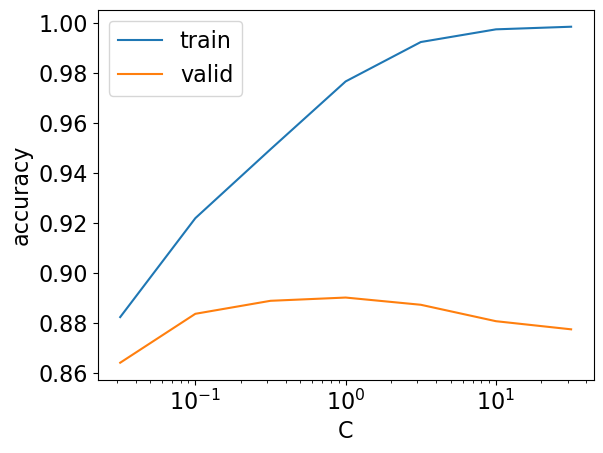

In [ ]:
train_scores = []
cv_scores = []

C_vals = 10.0 ** np.arange(-1.5, 2, 0.5)

for C in C_vals:
    #     print(C)
    pipe = make_pipeline(
        CountVectorizer(stop_words="english"),
        LogisticRegression(max_iter=1000, C=C, random_state=123),
    )
    cv_results = cross_validate(pipe, X_train, y_train, return_train_score=True)

    train_scores.append(cv_results["train_score"].mean())
    cv_scores.append(cv_results["test_score"].mean())

plt.semilogx(C_vals, train_scores, label="train")
plt.semilogx(C_vals, cv_scores, label="valid")
plt.legend()
plt.xlabel("C")
plt.ylabel("accuracy");

In [ ]:
pd.DataFrame({"C": C_vals, "train": train_scores, "cv": cv_scores})

,C,train,cv
0,0.031623,0.882479,0.864259
1,0.100000,0.921983,0.883795
2,0.316228,0.949485,0.888985
3,1.000000,0.976590,0.890283
4,3.162278,0.992323,0.887399
5,10.000000,0.997387,0.880839
6,31.622777,0.998432,0.877595


<div class="alert alert-warning">

Solution_3.2
    
</div>

_Points:_ 2

It seems here the best value of C is 1.0. At this point, the cross-validation score is at its max. We note that larger C-values have a higher train accuracy but a lower CV score, which leads us to believe that the models with those hyperparameters are overfitting. 

<!-- END QUESTION -->

<br><br>

### 3.3 Jointly optimizing `max_features` of `CountVectorizer` and `C` of `LogisticRegression` using `GridSearchCV`
rubric={points}

So far we have been writing loops to try a bunch of different hyperparameter values and pick the one with lowest cross-validation error. This operation is so common that `scikit-learn` has some built-in classes to do it for you. In this and the next exercise, we will explore two such classes:

1. [`sklearn.model_selection.GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) 
2. [`sklearn.model_selection.RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

Start with the pipeline `pipe_lr` below.

**Your tasks:**
- Create a `GridSearchCV` object named `grid_search` to jointly optimize `max_features` of `CountVectorizer` and `C` of `LogisticRegression` across all the combinations of values we tried above. 
- What are the best values of `max_features` and `C` according to your grid search? Store them in variables `best_max_features` and `best_C`, respectively.  
- Store the best score returned by the grid search in a variable called `best_score`. 

> The code might be a bit slow here. Setting `n_jobs=-1` should speed it up if you have a multi-core processor.

In [ ]:
pipe_lr = make_pipeline(
    CountVectorizer(stop_words="english"),
    LogisticRegression(max_iter=1000, random_state=123),
)

<div class="alert alert-warning">

Solution_3.3
    
</div>

_Points:_ 6

In [53]:
param_grid = {
    "countvectorizer__max_features": [10, 100, 1000, 10_000, 100_000],
    "logisticregression__C": 10.0 ** np.arange(-1.5, 2, 0.5),
}
grid_search = GridSearchCV(pipe_lr, param_grid, cv=5, n_jobs = -1, return_train_score=True)
grid_search.fit(X_train, y_train)

best_max_features = grid_search.best_params_["countvectorizer__max_features"]
best_C = grid_search.best_params_["logisticregression__C"]
best_score = grid_search.best_score_

In [54]:
best_max_features

100000

In [55]:
best_C

np.float64(1.0)

In [56]:
best_score

np.float64(0.8902830010977091)

<br><br>

<!-- BEGIN QUESTION -->

### 3.4 Jointly optimizing `max_features` of `CountVectorizer` and `C` of `LogisticRegression` with `RandomizedSearchCV`
rubric={points}

**Your tasks:**

1. Jointly optimize `C` hyperparameter for the `LogisticRegression`, as well as the `max_features` hyperparameter for the `CountVectorizer` using [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html). Choose reasonable ranges or distributions for the hyperparameters, using either a parameter grid or appropriate distributions at your discretion.
2. Display the best hyperparameter values and the best score found. 

<div class="alert alert-warning">

Solution_3.4
    
</div>

_Points:_ 5

In [57]:

from scipy.stats import loguniform

param_dist = {
    "countvectorizer__max_features": [1000, 5000, 10000, 50000, 100000],
    "logisticregression__C": loguniform(0.01, 10.0)
}


random_search = RandomizedSearchCV(
    pipe_lr, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=5, 
    n_jobs=-1, 
    random_state=123,
    return_train_score=True
)


random_search.fit(X_train, y_train)

best_random_max_features = random_search.best_params_["countvectorizer__max_features"]
best_random_C = random_search.best_params_["logisticregression__C"]
best_random_score = random_search.best_score_



In [58]:
best_random_max_features

100000

In [59]:
best_random_C

np.float64(0.7859158600294538)

In [60]:
best_random_score

np.float64(0.8903549432633788)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 3.5 Discussion 
rubric={points}

- Do the best hyperparameter values found through grid search and random search match each other and the results you obtained in 3.1 and 3.2?
- More generally, should these values be expected to match the ones you found in parts 3.1 and 3.2? Why or why not?

<div class="alert alert-warning">

Solution_3.5
    
</div>

_Points:_ 2

1. Yes, they match well. The GridSearchCV parameters (max_features = 100000, C=1.0) are an exact match. We also notice that that RandomizedSearchCV closely matches them as well. It selected the max_features space to be 100,000 and found a continuous C value of ~0.7859. This C-value still lands in the "neighborhood"/range of C=1.0, and actually, we observe that with that C value, we obtain a slightly higher validation score of 0.8903549. 

2. No, not necessarily. In parts 3.1 and 3.2, we optimized one hyperparameter at a time and kept the other one fixed. This method ignores the possibility of any potential "interaction" side-effects between the two parameters. 

<!-- END QUESTION -->

<br><br>

### 3.6 Test score
rubric={points}

**Your tasks:**
- Evaluate your final model on the test set. Store the test accuracy in the variable called `test_score`.

<div class="alert alert-warning">

Solution_3.6
    
</div>

_Points:_ 2

In [52]:
test_score = grid_search.score(X_test, y_test)
test_score

0.8904736275565124

<br><br>

<!-- BEGIN QUESTION -->

### 3.7 Discussion
rubric={points}

- How does your test accuracy compare to your validation accuracy? 
- If they are different: do you think this is because you "overfitted on the validation set", or simply random luck?

<div class="alert alert-warning">

Solution_3.7
    
</div>

_Points:_ 2

Our test accuracy came out to 0.8904736 whilst the validation accuracy (from 3.3) came out to 0.89028. There is a neglible difference but since the scores are almost identical, I see no indication of the model overfitting. Instead, this almost match seems to confirm that our 5-fold CV is robust and estimates the model's generaliaztion performance well. If we have to say any difference, it is probably due to some minor differences/changes when performing the data-split. 

<!-- END QUESTION -->

<br><br><br><br>

<!-- BEGIN QUESTION -->

## Exercise 4: Very short answer questions
<hr>
rubric={points}

Each question is worth 2 points. Max 2 sentences per answer.

1. What is the problem with calling `fit_transform` on your test data with `CountVectorizer`? 
2. If you could only access one of `predict` or `predict_proba`, which one would you choose? Briefly explain.
3. What are two advantages of `RandomizedSearchCV` over `GridSearchCV`?

<div class="alert alert-warning">

Solution_4
    
</div>

_Points:_ 6

1. Calling fit_transform on the test data causes data leakage because it allows the vectorizer to leanr new vocabulary and word frequency directly from the test set. This violates the golden rule of machine learning, leading to an overly optimistic performance that may not generalize well to unseen data.
2. I would choose predict_proba because it provides the raw continuous probability scores for each class rather than just a hard binary label. Having access to these underlying probabilities allows us to manually apply our own classification logic and analyze prediction confidence.
3. First, RandomizedSearchCV is signficantly more efficient than GridSearchCV as you can explicitly cap the number of iterations rather than checking every single combination. Secondly, it can sample from continuous distributions rather than fixed intervals like GridSearchCV, allowing it to discover possibly optimal hyperparameter values that may not be discovered in a predefined grid. 

<!-- END QUESTION -->

<br><br><br><br>

Here is a quick checklist before submitting:  

- [ ] Restart the kernel and run all cells.  
- [ ] `hw4.ipynb` runs without errors and contains all outputs.  
- [ ] Save `hw4.ipynb` in JupyterLab.  
- [ ] Return to the PrairieLearn question page and click **Save only** to check the rendered notebook preview.  
- [ ] When the preview looks correct, click **Save & Grade**.  
- [ ] If you are working in a group, confirm your PrairieLearn group membership is correct.  
- [ ] Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for details on the grading process.


Congratulations on finishing the homework! 

![](./img/eva-well-done.png)